In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

df = pd.read_csv(r"C:\Users\hawra\Desktop\Absenteeism at work An UCI dataset\Absenteeism_at_work.csv")
df.head()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,239.554,...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239.554,...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,2


In [3]:
print(df.shape)

df.info()

print(df.isnull().sum())

print(df.duplicated().sum())

print(df.dtypes)

(740, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               740 non-null    int64  
 1   Reason for absence               740 non-null    int64  
 2   Month of absence                 740 non-null    int64  
 3   Day of the week                  740 non-null    int64  
 4   Seasons                          740 non-null    int64  
 5   Transportation expense           740 non-null    int64  
 6   Distance from Residence to Work  740 non-null    int64  
 7   Service time                     740 non-null    int64  
 8   Age                              740 non-null    int64  
 9   Work load Average/day            740 non-null    float64
 10  Hit target                       740 non-null    int64  
 11  Disciplinary failure             740 non-null    int64  
 12  Education   

In [5]:
#removing dublicates becouse repeated rows distort the analysis
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (706, 21)


In [6]:
#replacing spaces in the col names with _
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
df.head(2)

,id,reason_for_absence,month_of_absence,day_of_the_week,seasons,transportation_expense,distance_from_residence_to_work,service_time,age,work_load_average/day,...,disciplinary_failure,education,son,social_drinker,social_smoker,pet,weight,height,body_mass_index,absenteeism_time_in_hours
0,11,26,7,3,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,1,0,0,98,178,31,0


In [21]:
# Detect outliers for absenteeism_time_in_hours
Q1 = df['absenteeism_time_in_hours'].quantile(0.25)
Q3 = df['absenteeism_time_in_hours'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['absenteeism_time_in_hours'] < Q1 - 1.5*IQR) | (df['absenteeism_time_in_hours'] > Q3 + 1.5*IQR)]
print("Number of outliers:", outliers.shape[0])

Number of outliers: 44


In [35]:
#Outliers removed because it can skew visualizations
numeric_cols = ['distance_from_residence_to_work', 'age', 'work_load_average/day', 'absenteeism_time_in_hours']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (628, 21)


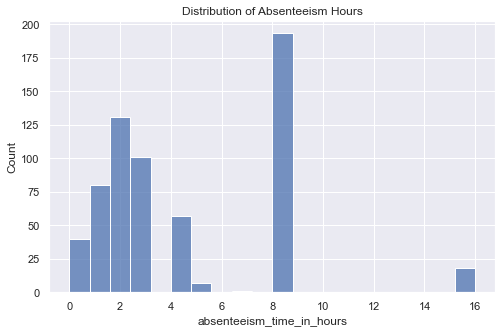

' why :\nto show the spread of the data \ninsight:\nmost absences occur as full 8 hour shifts, showing that people take off a full worday. also there\nare a cluster between 1 and 4 hours likely foe appiontments.'

In [62]:
# Histogram of absenteeism hours to see the distribution
plt.figure(figsize=(8,5))
sns.histplot(df['absenteeism_time_in_hours'], bins=20)
plt.title("Distribution of Absenteeism Hours")
plt.show()

""" why :
to show the spread of the data 
insight:
most absences occur as full 8 hour shifts, showing that people take off a full worday. also there
are a cluster between 1 and 4 hours likely foe appiontments."""

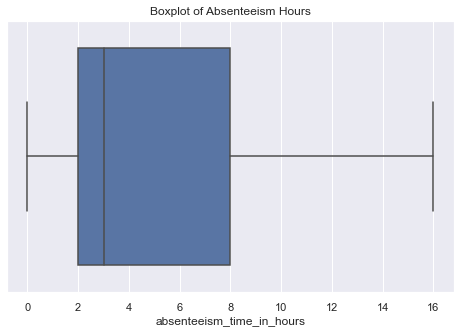

'why :\nto understand the spread of the data \ninsight:\nthe median is around 3 hours meaning most absences are short'

In [63]:
# Boxplot to detect outliers visually in absenteeism hours
plt.figure(figsize=(8,5))
sns.boxplot(x=df['absenteeism_time_in_hours'])
plt.title("Boxplot of Absenteeism Hours")
plt.show()
"""why :
to understand the spread of the data 
insight:
the median is around 3 hours meaning most absences are short"""

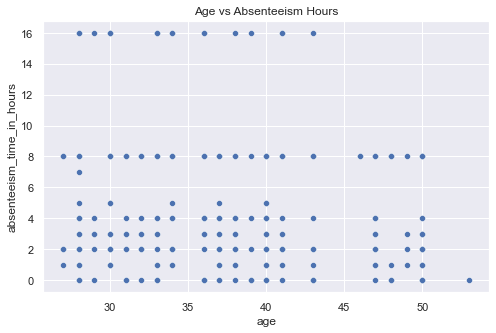

' why :\nto see if younger or older employees tend to miss more work\ninsight:\nthere are no strong relationship between the age and absenteeism hours \nthe absences occur across all ages'

In [64]:
# Scatter plot showing relationship between age and absenteeism hours
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='absenteeism_time_in_hours', data=df)
plt.title("Age vs Absenteeism Hours")
plt.show()
""" why :
to see if younger or older employees tend to miss more work
insight:
there are no strong relationship between the age and absenteeism hours 
the absences occur across all ages"""

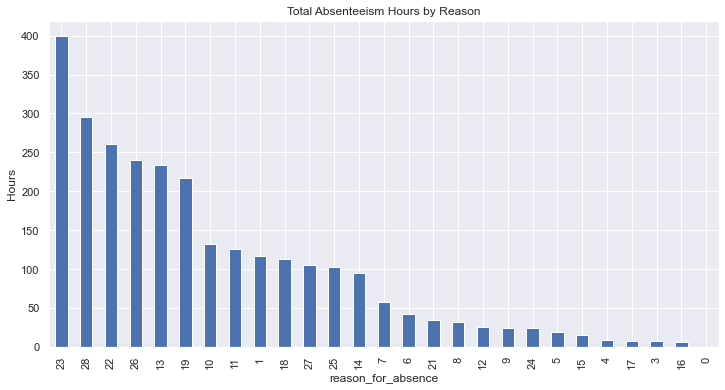

' why :\nto pinpoint the primary causes of absences\ninsight:\nthe top 6 reasons especilly 23 and 28 drive the vast majority of absences\nwhile others have a litle impact'

In [65]:
# Bar chart showing total absenteeism hours grouped by reason for absence
reason_hours = df.groupby('reason_for_absence')['absenteeism_time_in_hours'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
reason_hours.plot(kind='bar')
plt.title("Total Absenteeism Hours by Reason")
plt.ylabel("Hours")
plt.show()
""" why :
to pinpoint the primary causes of absences
insight:
the top 6 reasons especilly 23 and 28 drive the vast majority of absences
while others have a litle impact"""

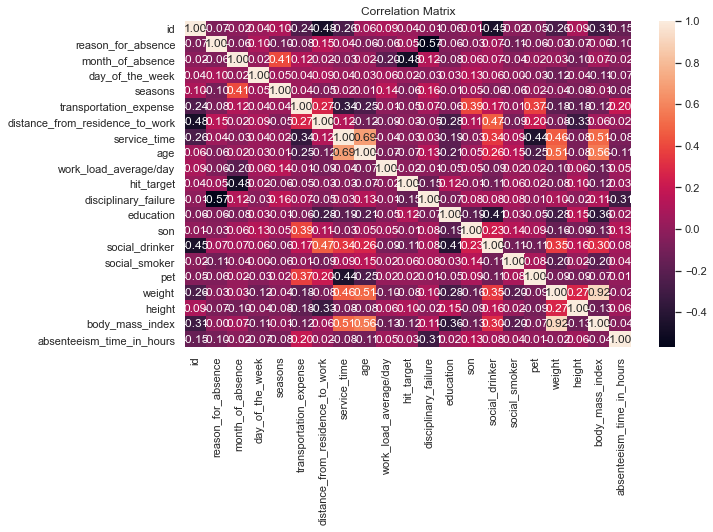

' why :\nto identify the factor directly influence the duration of absenteeism\ninsight:\nthe strongest relationship is between body mass index and weight(0.92), also the relationship between sercies time and age is moderate(0.69)\n'

In [66]:
# Correlation heatmap for numeric columns to show relationships
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()
""" why :
to identify the factor directly influence the duration of absenteeism
insight:
the strongest relationship is between body mass index and weight(0.92), also the relationship between sercies time and age is moderate(0.69)
"""

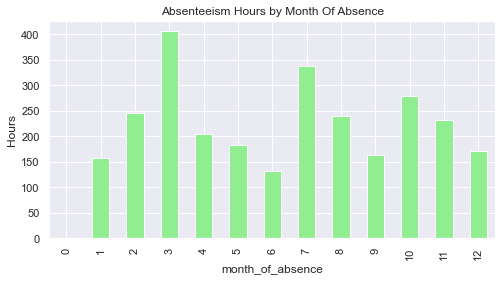

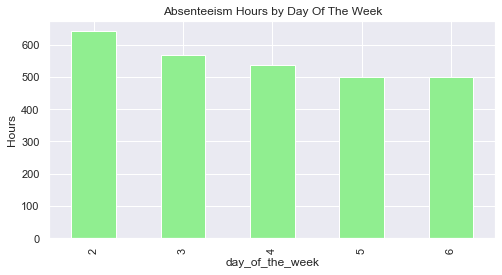

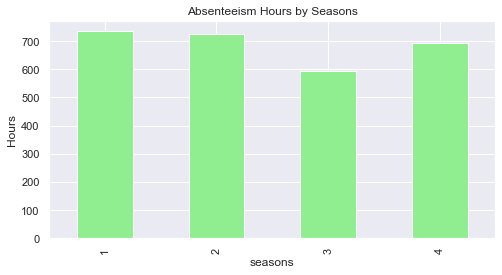

In [67]:

# Bar plots showing total absenteeism hours per category
import matplotlib.pyplot as plt
categorical_cols = ['month_of_absence', 'day_of_the_week', 'seasons']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df.groupby(col)['absenteeism_time_in_hours'].sum().plot(kind='bar', color='lightgreen')
    plt.title(f"Absenteeism Hours by {col.replace('_',' ').title()}")
    plt.ylabel("Hours")
    plt.show()
    """why : to identify high risk times during the weel or year
    to show the spread of the data 
    insight:
    1- the most absecnces are in March and July
    2- absences are highest at the start of week
    3- autumn is the most stable period """


In [70]:
"""Conclusion
 absenteeism isn't random. Reasons 23 and 28 are the biggest drivers, and most lost hours happen on Mondays and during Spring. Surprisingly, factors like age and distance don't really affect the hours as much as I expected."""

"Conclusion\n absenteeism isn't random. Reasons 23 and 28 are the biggest drivers, and most lost hours happen on Mondays and during Spring. Surprisingly, factors like age and distance don't really affect the hours as much as I expected."